In [1]:
import pandas as pd
df_ambiente = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_Ambient_data.csv')
df_sensores = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_BaseLine_data.csv')

In [2]:
import pandas as pd
import numpy as np

def build_datetime(df):
    df = df.copy()

    df["DAY"] = df["DAY"].astype(str)
    df["YEAR"] = df["DAY"].str[:4].astype(int)
    df["DOY"] = df["DAY"].str[4:].astype(int)

    df["DATE"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
        format="%Y%j"
    )

    df["DATETIME"] = pd.to_datetime(
        df["DATE"].astype(str) + " " + df["HOUR"].astype(str)
    )

    return df.drop(columns=["YEAR", "DOY", "DATE"])

baseline = build_datetime(df_ambiente)
baseline = baseline.replace(32767, np.nan)
baseline = baseline.drop(columns=["Unnamed: 0"], errors="ignore")
baseline = baseline.drop_duplicates()

ambiental = build_datetime(df_sensores)
ambiental = ambiental.replace(32767, np.nan)
ambiental = ambiental.drop(columns=["Unnamed: 0"], errors="ignore")
ambiental = ambiental.drop_duplicates()

df = pd.merge(
    baseline,
    ambiental,
    on=["DAY", "HOUR", "DATETIME"],
    how="inner",
    suffixes=("_elec", "_amb")
)

df = df.sort_values("DATETIME")
df = df.set_index("DATETIME")

df = df[(df['DAY'] >= "2018001") & (df['DAY'] < "2024001")]

df_day = df[df["GHRADA"] > 100].copy()
display(df_day)

missing_values_percentage = df.isnull().sum() / len(df) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))

df_day["hour"] = df_day.index.hour
df_day["minute"] = df_day.index.minute
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month

,DAY,HOUR,GHRADA,DIRRAA,DIFRAA,PMBARA,WSMEAN,WDIREA,WDIRST,WSMSST,...,REC2RE,LAMBTA,POAIR1,ICP1JT,ICP2JT,ICP3JT,ICP4JT,ICP5JT,ICP6JT,ICP7JT
DATETIME,,,,,,,,,,,,,,,,,,,,,
2018-01-01 08:29:00,2018001,08:29:00,102.1,0.9,108.3,1019.6,0.00,0.0,0.00,0.00,...,0.00,15.69,98.3,22.35,23.23,0.0,0.0,21.39,18.49,19.02
2018-01-01 08:30:00,2018001,08:30:00,109.2,0.9,115.9,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.71,105.7,22.41,23.27,0.0,0.0,21.46,18.55,19.08
2018-01-01 08:31:00,2018001,08:31:00,112.5,0.9,119.8,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.82,110.7,22.45,23.34,0.0,0.0,21.52,18.62,19.11
2018-01-01 08:32:00,2018001,08:32:00,111.3,0.9,119.2,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.92,111.6,22.49,23.45,0.0,0.0,21.57,18.67,19.14
2018-01-01 08:33:00,2018001,08:33:00,109.6,0.9,117.4,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.91,111.1,22.57,23.60,0.0,0.0,21.58,18.74,19.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 16:23:00,2023365,16:23:00,186.3,429.7,97.3,1022.4,1.52,241.0,19.08,0.63,...,0.02,137.44,354.8,26.88,27.37,0.0,0.0,25.55,22.87,23.74
2023-12-31 16:24:00,2023365,16:24:00,211.5,527.8,100.6,1022.4,0.86,234.0,16.97,0.72,...,0.02,138.17,380.6,26.90,27.36,0.0,0.0,25.53,22.84,23.72
2023-12-31 16:25:00,2023365,16:25:00,179.5,421.7,92.6,1022.4,1.67,232.1,21.97,0.45,...,0.02,138.67,348.6,26.93,27.35,0.0,0.0,25.48,22.83,23.69


REC1TE    47.960533
REC2TE    47.551727
DIRRAA    13.011372
MODT07     5.500057
MODT08     5.499962
            ...    
WSMSST     0.831051
WDIRST     0.831051
WDIREA     0.831051
WSMEAN     0.831051
PMBARA     0.831051
Length: 68, dtype: float64

Variables usadas:
['S2WACA', 'GHRADA', 'TMPCAV', 'RHPCTA', 'WSMEAN', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'power_per_irradiance', 'log_power', 'log_irradiance', 'power_irradiance_gap']
Tamaño dataset: (1232612, 13)
Train: (935561, 13)
Val: (196038, 13)
Test: (101013, 13)
Tamaño train original: (935561, 13)
Tamaño train limpio: (712286, 13)
Porcentaje conservado: 76.13 %
Umbral Isolation Forest: -0.007651210855687439

Anomalías estadísticas IF:
anomaly_iso
0    96.705375
1     3.294625
Name: proportion, dtype: float64


,n_anomalias,porcentaje
anomaly_iso,3328.0,3.2946
anomaly_low_power_with_sun,770.0,0.7623
anomaly_high_irr_very_low_power,72.0,0.0713
anomaly_mid_irr_low_power,5638.0,5.5815
anomaly_low_efficiency,182.0,0.1802
anomaly_high_irr_low_power,209.0,0.2069
anomaly_clear_failure,821.0,0.8128
anomaly_moderate_underproduction,342.0,0.3386
anomaly_final_iso,940.0,0.9306


Número total de anomalías finales: 940
Porcentaje de anomalías finales: 0.9306 %


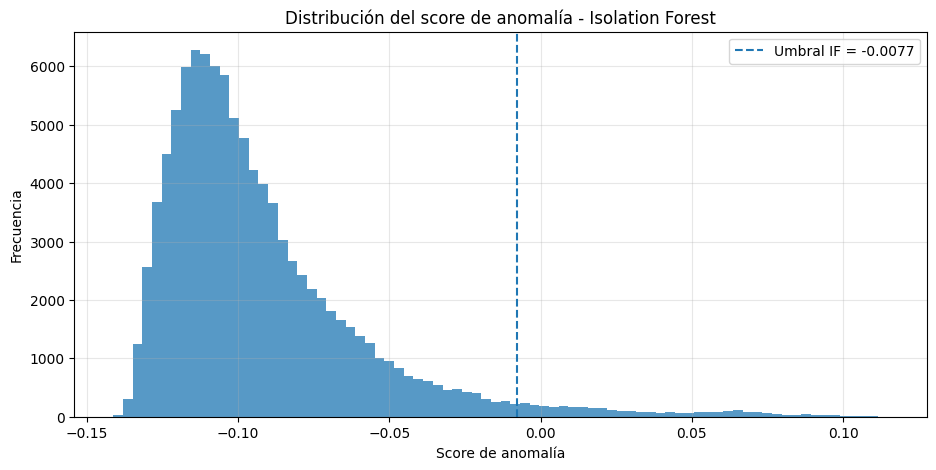

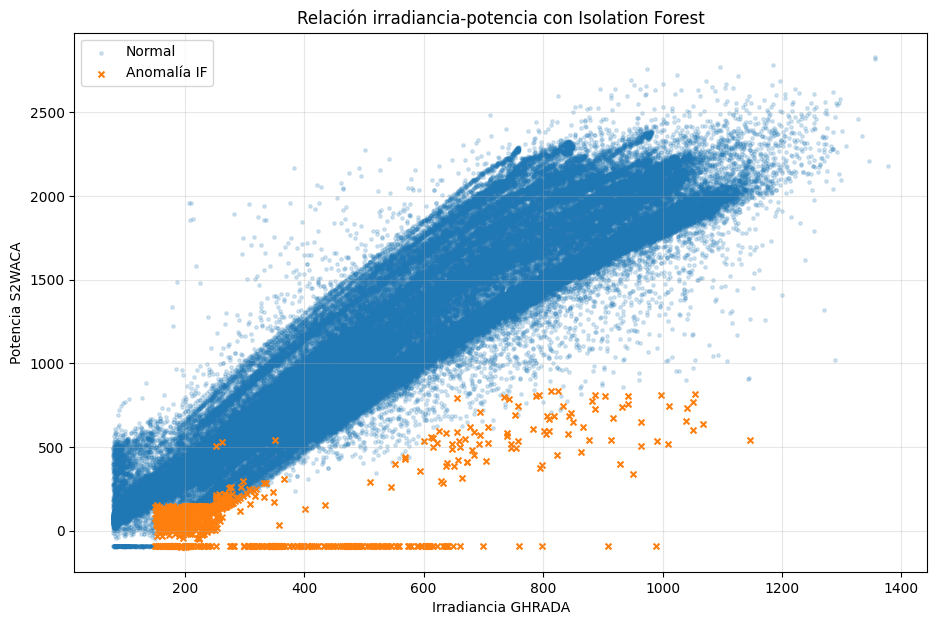

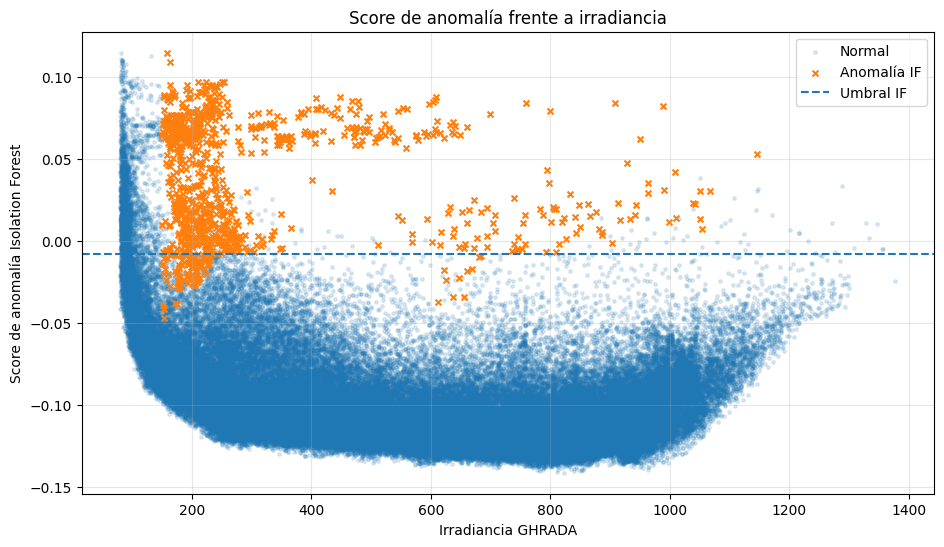

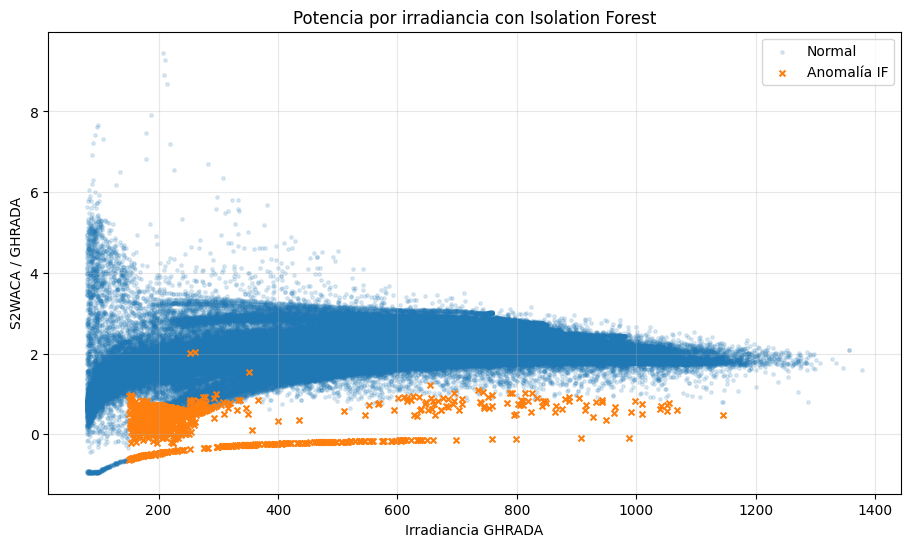

,S2WACA,GHRADA,TMPCAV,RHPCTA,WSMEAN,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,power_per_irradiance,...,iso_anomaly_score,anomaly_iso,anomaly_low_power_with_sun,anomaly_high_irr_very_low_power,anomaly_mid_irr_low_power,anomaly_low_efficiency,anomaly_high_irr_low_power,anomaly_clear_failure,anomaly_moderate_underproduction,anomaly_final_iso
DATETIME,,,,,,,,,,,,,,,,,,,,,
2024-02-02 16:59:00,110.5,173.4,22.63,38.43,1.23,-0.866025,-0.500000,0.538005,0.842942,0.637255,...,0.015546,1,1,0,0,0,0,1,0,1
2024-02-02 17:00:00,30.7,171.2,22.57,39.03,1.60,-0.965926,-0.258819,0.538005,0.842942,0.179322,...,0.089179,1,1,0,0,0,0,1,0,1
2024-02-02 17:01:00,24.2,168.6,22.50,38.98,0.96,-0.965926,-0.258819,0.538005,0.842942,0.143535,...,0.090121,1,1,0,0,0,0,1,0,1
2024-02-02 17:02:00,23.3,165.1,22.44,39.76,1.22,-0.965926,-0.258819,0.538005,0.842942,0.141127,...,0.088758,1,1,0,0,0,0,1,0,1
2024-02-02 17:03:00,12.8,161.4,22.36,39.80,1.69,-0.965926,-0.258819,0.538005,0.842942,0.079306,...,0.087713,1,1,0,0,0,0,1,0,1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline


# ============================================================
# 1. Preparación temporal
# ============================================================

df = pd.merge(
    baseline,
    ambiental,
    on=["DAY", "HOUR", "DATETIME"],
    how="inner",
    suffixes=("_elec", "_amb")
)

df = df.sort_values("DATETIME")
df = df.set_index("DATETIME")

df = df[
    (df["DAY"] >= "2018001") &
    (df["DAY"] < "2025001")
].copy()


# ============================================================
# 2. Filtrado diurno
# ============================================================

df_day = df[df["GHRADA"] > 80].copy()

df_day["hour"] = df_day.index.hour
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month

df_day["hour_sin"] = np.sin(2 * np.pi * df_day["hour"] / 24)
df_day["hour_cos"] = np.cos(2 * np.pi * df_day["hour"] / 24)

df_day["dayofyear_sin"] = np.sin(2 * np.pi * df_day["dayofyear"] / 365)
df_day["dayofyear_cos"] = np.cos(2 * np.pi * df_day["dayofyear"] / 365)


# ============================================================
# 3. Variables físicas derivadas
# ============================================================

target = "S2WACA"

df_day["power_per_irradiance"] = (
    df_day[target] /
    df_day["GHRADA"].clip(lower=100)
)

df_day["log_power"] = np.log1p(df_day[target].clip(lower=0))
df_day["log_irradiance"] = np.log1p(df_day["GHRADA"].clip(lower=0))

df_day["power_irradiance_gap"] = (
    df_day["log_irradiance"] - df_day["log_power"]
)


# ============================================================
# 4. Variables para Isolation Forest
# ============================================================

features_iso = [
    # Potencia del sistema que quieres vigilar
    "S2WACA",

    # Irradiancia
    "GHRADA",

    # Condiciones ambientales principales
    "TMPCAV",
    "RHPCTA",
    "WSMEAN",

    # Tiempo codificado de forma cíclica
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",

    # Variables físicas derivadas
    "power_per_irradiance",
    "log_power",
    "log_irradiance",
    "power_irradiance_gap"
]

features_iso = [
    col for col in features_iso
    if col in df_day.columns
]

data_iso = df_day[features_iso].copy()
data_iso = data_iso.replace([np.inf, -np.inf], np.nan)
data_iso = data_iso.dropna()

print("Variables usadas:")
print(features_iso)
print("Tamaño dataset:", data_iso.shape)


# ============================================================
# 5. Split temporal
# ============================================================

train = data_iso[data_iso.index < "2023-01-01"].copy()

val = data_iso[
    (data_iso.index >= "2023-01-01") &
    (data_iso.index < "2024-01-01")
].copy()

test = data_iso[
    (data_iso.index >= "2024-01-01") &
    (data_iso.index < "2025-01-01")
].copy()

print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)


# ============================================================
# 6. Limpieza del entrenamiento
# ============================================================

train_clean = train.copy()

train_clean = train_clean[
    (train_clean["GHRADA"] > 80) &
    (train_clean[target] > 0)
].copy()

if "RHPCTA" in train_clean.columns:
    train_clean = train_clean[
        train_clean["RHPCTA"].between(0, 100)
    ].copy()

if "TMPCAV" in train_clean.columns:
    train_clean = train_clean[
        train_clean["TMPCAV"].between(-10, 70)
    ].copy()

if "WSMEAN" in train_clean.columns:
    train_clean = train_clean[
        train_clean["WSMEAN"] >= 0
    ].copy()

# Eliminar casos claramente anómalos del entrenamiento:
# irradiancia alta pero potencia demasiado baja
train_clean = train_clean[
    ~(
        (train_clean["GHRADA"] > 500) &
        (train_clean[target] < 300)
    )
].copy()

# Recorte suave de potencia extrema
lower_power_limit = train_clean[target].quantile(0.001)
upper_power_limit = train_clean[target].quantile(0.999)

train_clean = train_clean[
    train_clean[target].between(
        lower_power_limit,
        upper_power_limit
    )
].copy()

print("Tamaño train original:", train.shape)
print("Tamaño train limpio:", train_clean.shape)
print(
    "Porcentaje conservado:",
    round(len(train_clean) / len(train) * 100, 2),
    "%"
)


# ============================================================
# 7. Entrenamiento del modelo no supervisado
# ============================================================

X_train = train_clean[features_iso]
X_val = val[features_iso]
X_test = test[features_iso]

iso_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", IsolationForest(
        n_estimators=500,
        max_samples=2048,
        contamination=0.02,
        max_features=0.80,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    ))
])

iso_model.fit(X_train)


# ============================================================
# 8. Score de anomalía
# ============================================================

val = val.copy()
test = test.copy()

val["iso_decision_score"] = iso_model.decision_function(X_val)
test["iso_decision_score"] = iso_model.decision_function(X_test)

# Score alto = más anómalo
val["iso_anomaly_score"] = -val["iso_decision_score"]
test["iso_anomaly_score"] = -test["iso_decision_score"]


# ============================================================
# 9. Umbral estadístico
# ============================================================

# Recomendación inicial:
# 0.970 detecta más que 0.975 sin dispararse.
threshold_iso = val["iso_anomaly_score"].quantile(0.970)

test["anomaly_iso"] = (
    test["iso_anomaly_score"] > threshold_iso
).astype(int)

print("Umbral Isolation Forest:", threshold_iso)

print("\nAnomalías estadísticas IF:")
print(test["anomaly_iso"].value_counts(normalize=True) * 100)


# ============================================================
# 10. Reglas físicas de interpretación
# ============================================================

# Fallo claro: potencia muy baja con sol
test["anomaly_low_power_with_sun"] = (
    (test["GHRADA"] > 150) &
    (test[target] < 150)
).astype(int)

# Fallo claro: irradiancia alta con potencia muy baja
test["anomaly_high_irr_very_low_power"] = (
    (test["GHRADA"] > 600) &
    (test[target] < 600)
).astype(int)

# Pérdida moderada: solo candidata
test["anomaly_mid_irr_low_power"] = (
    (test["GHRADA"] > 250) &
    (test["GHRADA"] <= 600) &
    (test[target] < 550)
).astype(int)

# Baja eficiencia relativa
test["anomaly_low_efficiency"] = (
    (test["GHRADA"] > 300) &
    (test["power_per_irradiance"] < 0.70)
).astype(int)

# Alta irradiancia con potencia algo baja
test["anomaly_high_irr_low_power"] = (
    (test["GHRADA"] > 600) &
    (test[target] < 850)
).astype(int)


# ============================================================
# 11. Anomalía final recomendada
# ============================================================

# Fallos claros: entran siempre
test["anomaly_clear_failure"] = (
    (test["anomaly_low_power_with_sun"] == 1) |
    (test["anomaly_high_irr_very_low_power"] == 1)
).astype(int)

# Fallos moderados: necesitan confirmación del Isolation Forest
test["anomaly_moderate_underproduction"] = (
    (
        (test["anomaly_mid_irr_low_power"] == 1) |
        (test["anomaly_low_efficiency"] == 1) |
        (test["anomaly_high_irr_low_power"] == 1)
    )
    &
    (test["anomaly_iso"] == 1)
).astype(int)

# Anomalía final
test["anomaly_final_iso"] = (
    (test["anomaly_clear_failure"] == 1) |
    (test["anomaly_moderate_underproduction"] == 1)
).astype(int)


# ============================================================
# 12. Resumen
# ============================================================

cols = [
    "anomaly_iso",
    "anomaly_low_power_with_sun",
    "anomaly_high_irr_very_low_power",
    "anomaly_mid_irr_low_power",
    "anomaly_low_efficiency",
    "anomaly_high_irr_low_power",
    "anomaly_clear_failure",
    "anomaly_moderate_underproduction",
    "anomaly_final_iso"
]

resumen = {}

for col in cols:
    resumen[col] = {
        "n_anomalias": int(test[col].sum()),
        "porcentaje": round(test[col].mean() * 100, 4)
    }

display(pd.DataFrame(resumen).T)

print("Número total de anomalías finales:", int(test["anomaly_final_iso"].sum()))
print(
    "Porcentaje de anomalías finales:",
    round(test["anomaly_final_iso"].mean() * 100, 4),
    "%"
)


# ============================================================
# 13. Gráficas
# ============================================================

def plot_iso_score_distribution(test, threshold_iso):
    plt.figure(figsize=(11, 5))

    plt.hist(
        test["iso_anomaly_score"],
        bins=80,
        alpha=0.75
    )

    plt.axvline(
        threshold_iso,
        linestyle="--",
        label=f"Umbral IF = {threshold_iso:.4f}"
    )

    plt.title("Distribución del score de anomalía - Isolation Forest")
    plt.xlabel("Score de anomalía")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_irradiance_power_iso(test, target="S2WACA"):
    normal = test[test["anomaly_final_iso"] == 0]
    anomaly = test[test["anomaly_final_iso"] == 1]

    plt.figure(figsize=(11, 7))

    plt.scatter(
        normal["GHRADA"],
        normal[target],
        s=6,
        alpha=0.18,
        label="Normal"
    )

    plt.scatter(
        anomaly["GHRADA"],
        anomaly[target],
        s=18,
        marker="x",
        label="Anomalía IF"
    )

    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel(f"Potencia {target}")
    plt.title("Relación irradiancia-potencia con Isolation Forest")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_iso_score_vs_irradiance(test, threshold_iso):
    normal = test[test["anomaly_final_iso"] == 0]
    anomaly = test[test["anomaly_final_iso"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["GHRADA"],
        normal["iso_anomaly_score"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["GHRADA"],
        anomaly["iso_anomaly_score"],
        s=18,
        marker="x",
        label="Anomalía IF"
    )

    plt.axhline(
        threshold_iso,
        linestyle="--",
        label="Umbral IF"
    )

    plt.title("Score de anomalía frente a irradiancia")
    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel("Score de anomalía Isolation Forest")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_power_per_irradiance_iso(test):
    normal = test[test["anomaly_final_iso"] == 0]
    anomaly = test[test["anomaly_final_iso"] == 1]

    plt.figure(figsize=(11, 6))

    plt.scatter(
        normal["GHRADA"],
        normal["power_per_irradiance"],
        s=6,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anomaly["GHRADA"],
        anomaly["power_per_irradiance"],
        s=18,
        marker="x",
        label="Anomalía IF"
    )

    plt.title("Potencia por irradiancia con Isolation Forest")
    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel("S2WACA / GHRADA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_iso_score_distribution(test, threshold_iso)
plot_irradiance_power_iso(test, target=target)
plot_iso_score_vs_irradiance(test, threshold_iso)
plot_power_per_irradiance_iso(test)


# ============================================================
# 14. Export opcional
# ============================================================

anomalias_iso = test[test["anomaly_final_iso"] == 1].copy()

display(anomalias_iso.head())